#**NLP Text Preprocessing & HR Attrition Feature Engineering**
###  End-to-End Data Preprocessing Pipeline

**Author:** Aketch Adhiambo Okoth  

---

## **Project Overview**

This notebook delivers two complete, production-ready preprocessing pipelines on real-world datasets:

| Pipeline | Domain | Dataset | Core Techniques |
|---|---|---|---|
| **Part 1 — NLP** | News article auto-classification | 127,375 articles | Stop word removal · Regex · TF-IDF |
| **Part 2 — HR Analytics** | Employee attrition prediction | 1,470 employees | Imputation · Discretization · OHE · Target encoding |

---

In [1]:
score = {}

In [2]:
# Core libraries — imported once at the top for clean notebook execution
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 20)
print('Libraries loaded successfully.')

Libraries loaded successfully.


---
# PART 1 — News Article NLP Preprocessing Pipeline

**Business problem:** A news aggregator app needs an algorithm that automatically tags incoming articles into categories (politics, sports, entertainment) based on content — without manual review. Raw text must be cleaned and vectorized before any classifier can be trained.

**NLP pipeline steps:** Remove nulls → Lowercase → Strip stop words → Remove special chars → TF-IDF vectorize

In [3]:
import pandas as pd
import numpy as np

url = 'https://drive.google.com/file/d/1EKWpTfD8jGVYnesfLNpOOEr2wu6p7zeg/view?usp=sharing'
file_id = url.split('/')[-2]
download_link = 'https://drive.google.com/uc?export=download&id=' + file_id
df = pd.read_csv(download_link)

# only use the below code if you reach download limit on G-Drive
# df = pd.read_csv('https://raw.githubusercontent.com/marineevy/datasets/main/news.csv')
# df = pd.read_csv('/content/news.csv')

print(df.shape)
df.head(2)

(127393, 3)


,date,text,label
0,2018-01-04T15:35:56,Farmers will get subsidies for turning fields ...,politic
1,2018-01-04T15:35:57,Vanuatu bans non-biodegradable plastic to prot...,politic


In [4]:
# Dataset quick-look: label distribution and null check
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Article count by category:')
print(df['label'].value_counts().to_string())

Missing values per column:
date      0
text     18
label     0
dtype: int64

Article count by category:
label
politic       53762
science       39041
technology    34590


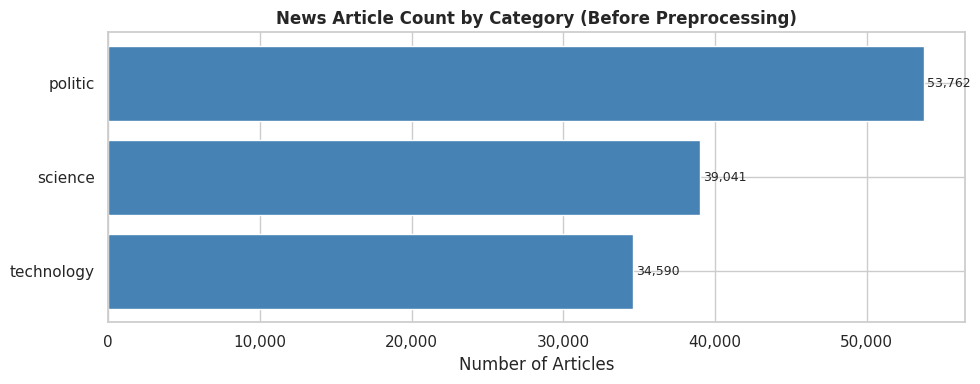

Total categories: 3 | Total articles: 127,393


In [5]:
# Visualization: Article category distribution
fig, ax = plt.subplots(figsize=(10, 4))
label_counts = df['label'].value_counts()
bars = ax.barh(label_counts.index, label_counts.values,
               color='steelblue', edgecolor='white')
for bar, val in zip(bars, label_counts.values):
    ax.text(val + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
ax.set_title('News Article Count by Category (Before Preprocessing)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Articles')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('news_category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Total categories: {df["label"].nunique()} | Total articles: {len(df):,}')

---
## Question 1 — Remove Null Text Rows

**Why this step matters:** Articles with no text have zero classification signal. Keeping null rows causes errors in every downstream NLP step — tokenization, stop word removal, and vectorization all fail on NaN values.

In [6]:
# Number of rows before
before = len(df)
null_text = df['text'].isnull().sum()

print(f'Rows before removal  : {before:,}')
print(f'Null text rows found : {null_text:,}')

# Remove rows where text is null
df = df.dropna(subset=['text'])

print(f'Rows after removal   : {len(df):,}')
print(f'Rows removed         : {before - len(df):,}')

Rows before removal  : 127,393
Null text rows found : 18
Rows after removal   : 127,375
Rows removed         : 18


In [7]:
df.shape

(127375, 3)

In [8]:
try:
    if (df.shape[0] == 127375):
        score['question 1'] = 'pass'
    else:
        score['question 1'] = 'fail'
except:
    score['question 1'] = 'fail'

score

{'question 1': 'pass'}

---
## Question 2 — Convert Text to Lowercase

**Why this step matters:** Without normalization, `Parliament`, `parliament`, and `PARLIAMENT` are three separate TF-IDF features. Lowercasing merges all variants into one token, shrinking the vocabulary and making word frequency counts accurate.

In [9]:
# Show before/after on the same article
print('BEFORE:', df['text'].iloc[2][:100])

# Convert text column to lowercase
df['text'] = df['text'].str.lower()

print('AFTER :', df['text'].iloc[2][:100])
print()
print('Verification — row[0][:7]:', df['text'][0][:7])
print('Verification — row[1][:7]:', df['text'][1][:7])

BEFORE: Ex-British PM Tony Blair ups calls for Labour to back Brexit U-turn - Former UK Prime Minister Blair
AFTER : ex-british pm tony blair ups calls for labour to back brexit u-turn - former uk prime minister blair

Verification — row[0][:7]: farmers
Verification — row[1][:7]: vanuatu


In [10]:
df['text'][0]

'farmers will get subsidies for turning fields back into wildflower meadows after brexit: more than 97% of the uk’s wildflower meadows have been destroyed since the second world war and their loss has played a significant role in the falling numbers of bees, birds and other wildlife.'

In [11]:
try:
    if ((df['text'][0][:7] == 'farmers') and (df['text'][1][:7] == 'vanuatu')):
        score['question 2'] = 'pass'
    else:
        score['question 2'] = 'fail'
except:
    score['question 2'] = 'fail'

score

{'question 1': 'pass', 'question 2': 'pass'}

---
## Question 3 — Remove Stop Words

**Why this step matters:** Stop words (the, will, is, and, but) appear in almost every article regardless of category, so they carry zero discriminative signal. Removing them reduces vocabulary size and lets the classifier focus on meaningful domain words like `election`, `parliament`, `goal`, `match`.

> **Example:** `"Farmers will get subsidies"` → `"farmers get subsidies"`

In [12]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))
print(f'English stop words loaded: {len(stop_words)}')

# Sample before removal
sample_before = df['text'].iloc[0]
words_before  = len(sample_before.split())

def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

df['text'] = df['text'].apply(remove_stopwords)

words_after = len(df['text'].iloc[0].split())
print(f'Words in article[0] before : {words_before}')
print(f'Words in article[0] after  : {words_after}')
print(f'Words removed              : {words_before - words_after}')
print()
print('Text after stop word removal:')
print(df['text'][0])

English stop words loaded: 198
Words in article[0] before : 47
Words in article[0] after  : 27
Words removed              : 20

Text after stop word removal:
farmers get subsidies turning fields back wildflower meadows brexit: 97% uk’s wildflower meadows destroyed since second world war loss played significant role falling numbers bees, birds wildlife.


In [13]:
df['text'][0]

'farmers get subsidies turning fields back wildflower meadows brexit: 97% uk’s wildflower meadows destroyed since second world war loss played significant role falling numbers bees, birds wildlife.'

In [14]:
try:
    if (df['text'][0][8:11] == 'get'):
        score['question 3'] = 'pass'
    else:
        score['question 3'] = 'fail'
except:
    score['question 3'] = 'fail'

score

{'question 1': 'pass', 'question 2': 'pass', 'question 3': 'pass'}

---
## Question 4 — Remove Numbers and Special Characters

**Why this step matters:** Numbers, percentages (`97%`), quotation marks, and punctuation vary unpredictably across articles and add noise. The regex pattern `[^a-zA-Z]` keeps only alphabetic characters, and collapsing multiple spaces ensures clean word boundaries for tokenization.

In [15]:
import re

print('BEFORE:')
print(df['text'].iloc[0][:150])
print()

# Remove all non-alphabetic characters
df['text'] = df['text'].str.replace(r'[^a-zA-Z]', ' ', regex=True)

# Collapse multiple spaces and strip leading/trailing whitespace
df['text'] = df['text'].str.replace(r'\s+', ' ', regex=True).str.strip()

print('AFTER:')
print(df['text'].iloc[0])
print()

# Verify: no digits or special characters remain
has_digit   = df['text'].str.contains(r'\d', regex=True).sum()
has_special = df['text'].str.contains(r'[^a-zA-Z ]', regex=True).sum()
print(f'Rows with remaining digits          : {has_digit}')
print(f'Rows with remaining special chars   : {has_special}')

BEFORE:
farmers get subsidies turning fields back wildflower meadows brexit: 97% uk’s wildflower meadows destroyed since second world war loss played signific

AFTER:
farmers get subsidies turning fields back wildflower meadows brexit uk s wildflower meadows destroyed since second world war loss played significant role falling numbers bees birds wildlife

Rows with remaining digits          : 0
Rows with remaining special chars   : 0


In [16]:
df['text'][0]

'farmers get subsidies turning fields back wildflower meadows brexit uk s wildflower meadows destroyed since second world war loss played significant role falling numbers bees birds wildlife'

In [17]:
try:
    if (df['text'][0] == 'farmers get subsidies turning fields back wildflower meadows brexit uk s wildflower meadows destroyed since second world war loss played significant role falling numbers bees birds wildlife'):
        score['question 4'] = 'pass'
    else:
        score['question 4'] = 'fail'
except:
    score['question 4'] = 'fail'

score

{'question 1': 'pass',
 'question 2': 'pass',
 'question 3': 'pass',
 'question 4': 'pass'}

---
## Question 5 — TF-IDF Vectorization

**Why this step matters:** ML models need numbers. TF-IDF converts each article into a vector where each dimension is a word's importance score:
- **TF (Term Frequency):** How often the word appears in this article
- **IDF (Inverse Document Frequency):** Downweights words common across all articles

Words distinctive to a category — `election`, `parliament` for politics; `goal`, `squad` for sports — receive high scores and become the primary classification signal.

> ⚠️ **Memory note:** The TF-IDF matrix for 127K articles is large. The function uses `.toarray()` which requires adequate RAM. Google Colab (free tier, ~12GB) handles this comfortably. The visualization below accesses only a **single row** (not the full matrix) to avoid MemoryError.

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

def create_tfidf_df(df):
    # Initialize TF-IDF Vectorizer
    vectorizer = TfidfVectorizer()

    # Fit and transform the text column
    tfidf_matrix = vectorizer.fit_transform(df['text'])

    # Convert to DataFrame
    tfidf_df = pd.DataFrame(tfidf_matrix.toarray(),
                            columns=vectorizer.get_feature_names_out())

    # Add the label column
    tfidf_df['label'] = df['label'].values

    return tfidf_df

#  NOTE: function returns tfidf_df directly (not a tuple)
tfidf_df = create_tfidf_df(df)

print(f'TF-IDF matrix built successfully.')
print(f'Shape : {tfidf_df.shape[0]:,} articles x {tfidf_df.shape[1]:,} features (incl. label)')
print(f'First feature : {tfidf_df.columns[0]}')
print(f'Last column   : {tfidf_df.columns[-1]}')

TF-IDF matrix built successfully.
Shape : 127,375 articles x 51,014 features (incl. label)
First feature : aa
Last column   : zyxel


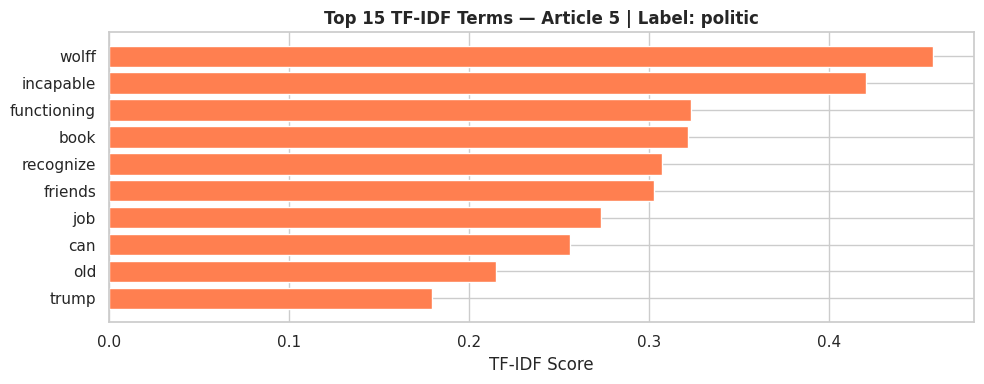

Vocabulary size (unique terms): 51,013
Label distribution in tfidf_df:
label
politic       53749
science       39038
technology    34588


In [19]:
# ── Memory-safe visualization: access ONE row only (not the full matrix) ─
# Get a single article row as a Series first, then drop the label entry
# This avoids the MemoryError caused by tfidf_df.drop('label', axis=1)
# which would copy the entire ~127K x 50K+ matrix.

sample_idx = 5
sample_label = tfidf_df['label'].iloc[sample_idx]

# iloc gets one row as Series → then drop label → filter nonzero → sort
sample_row   = tfidf_df.iloc[sample_idx].drop('label')
top_terms    = sample_row[sample_row > 0].sort_values(ascending=False).head(15)

if len(top_terms) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(top_terms.index[::-1], top_terms.values[::-1],
            color='coral', edgecolor='white')
    ax.set_title(f'Top 15 TF-IDF Terms — Article {sample_idx} | Label: {sample_label}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('TF-IDF Score')
    plt.tight_layout()
    plt.savefig('tfidf_top_terms.png', dpi=150, bbox_inches='tight')
    plt.show()

print(f'Vocabulary size (unique terms): {tfidf_df.shape[1] - 1:,}')
print(f'Label distribution in tfidf_df:')
print(tfidf_df['label'].value_counts().head(6).to_string())

In [20]:
tfidf_df

,aa,aaa,aaaaaetyw,aaas,aadhaar,aadholokam,aae,aagbfm,aakaweb,aalto,...,zuraibi,zurich,zuz,zuzana,zwaan,zwj,zx,zygosity,zynga,zyxel
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127370,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
127371,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
127372,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
127373,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
try:
    if ((tfidf_df.columns[0] == 'aa') & (tfidf_df.columns[-1] == 'zyxel')):
        score['question 5'] = 'pass'
    else:
        score['question 5'] = 'fail'
except:
    score['question 5'] = 'fail'

score

{'question 1': 'pass',
 'question 2': 'pass',
 'question 3': 'pass',
 'question 4': 'pass',
 'question 5': 'pass'}

---
# PART 2 — HR Attrition Feature Engineering Pipeline

**Business problem:** Employee turnover costs 50–200% of an annual salary per departing employee. HR wants to predict which employees are likely to leave so proactive retention strategies can be deployed. The raw HR dataset must be feature-engineered into a clean binary classification-ready format.

**Attrition rate:** 16.1% — 237 out of 1,470 employees left

In [22]:
import pandas as pd

url = 'https://drive.google.com/file/d/1-SGPhmw4F7hzBxeJv49lkHwj8yEGgG7S/view?usp=sharing'
file_id = url.split('/')[-2]
download_link = 'https://drive.google.com/uc?export=download&id=' + file_id
df = pd.read_csv(download_link)

# only use the below code if you reach download limit on G-Drive
# df = pd.read_csv('https://raw.githubusercontent.com/marineevy/datasets/main/hr_analytics.csv')
# df = pd.read_csv('/content/hr_analytics.csv')

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,...,PerformanceRating,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,3,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,3,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,3,80,1,6,3,3,2,2,2,2


In [23]:
# Dataset summary
print(f'Shape: {df.shape[0]:,} employees x {df.shape[1]} features')
print()
print('Attrition distribution:')
attrition_counts = df['Attrition'].value_counts()
print(attrition_counts)
print(f'Attrition rate: {attrition_counts["Yes"]/len(df)*100:.1f}%')

Shape: 1,470 employees x 32 features

Attrition distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition rate: 16.1%


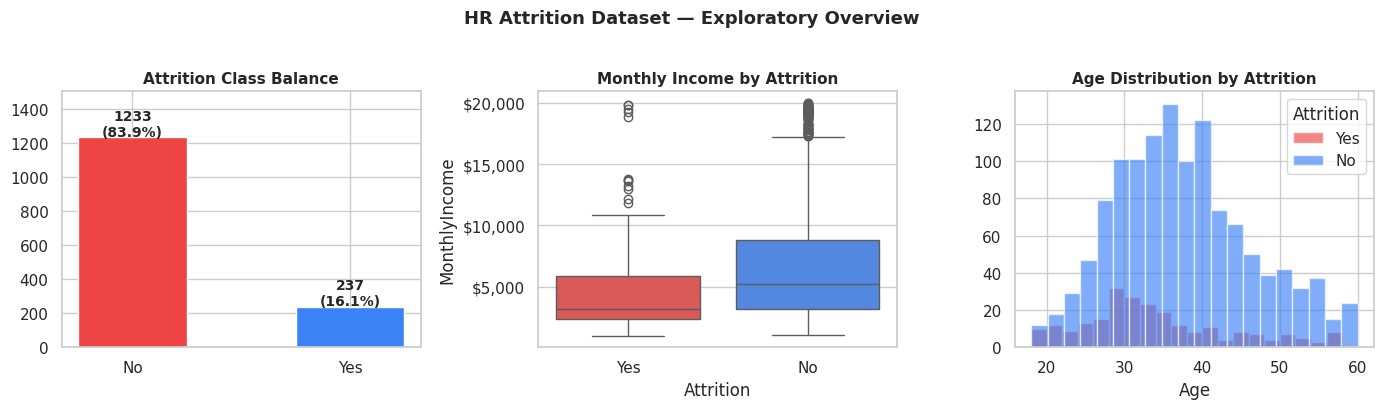

In [24]:
# Visualization: HR dataset EDA
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Attrition class balance
counts = df['Attrition'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=['#EF4444', '#3B82F6'], width=0.5, edgecolor='white')
for i, val in enumerate(counts.values):
    axes[0].text(i, val + 10, f'{val}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Attrition Class Balance', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, max(counts.values) * 1.22)

# Monthly income by attrition
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome',
            palette={'Yes': '#EF4444', 'No': '#3B82F6'}, ax=axes[1])
axes[1].set_title('Monthly Income by Attrition', fontsize=11, fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))

# Age distribution
for label, color in [('Yes', '#EF4444'), ('No', '#3B82F6')]:
    axes[2].hist(df[df['Attrition'] == label]['Age'],
                 bins=20, alpha=0.65, color=color, label=label, edgecolor='white')
axes[2].set_title('Age Distribution by Attrition', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Age')
axes[2].legend(title='Attrition')

plt.suptitle('HR Attrition Dataset — Exploratory Overview',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('hr_attrition_eda.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Question 6 — Identify Numerical and Categorical Variables

**Why this step matters:** Numerical and categorical variables require completely different preprocessing strategies. Correctly separating them — and explicitly excluding the target `Attrition` — ensures the right operation is applied to each feature type and prevents data leakage.

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1470 non-null   int64 
 1   Attrition                1470 non-null   object
 2   BusinessTravel           1470 non-null   object
 3   DailyRate                1470 non-null   int64 
 4   Department               1470 non-null   object
 5   DistanceFromHome         1470 non-null   int64 
 6   Education                1470 non-null   int64 
 7   EducationField           1470 non-null   object
 8   EmployeeCount            1470 non-null   int64 
 9   EmployeeID               1470 non-null   int64 
 10  Gender                   1470 non-null   object
 11  HourlyRate               1470 non-null   int64 
 12  JobInvolvement           1470 non-null   int64 
 13  JobLevel                 1470 non-null   int64 
 14  JobRole                  1470 non-null  

In [26]:
numerical_var   = [col for col in df.select_dtypes(include=['int64', 'float64']).columns
                   if col != 'Attrition']
categorical_var = [col for col in df.select_dtypes(include=['object']).columns
                   if col != 'Attrition']

print(f'Numerical variables   ({len(numerical_var)}): {numerical_var}')
print()
print(f'Categorical variables ({len(categorical_var)}): {categorical_var}')

Numerical variables   (23): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeID', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical variables (8): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


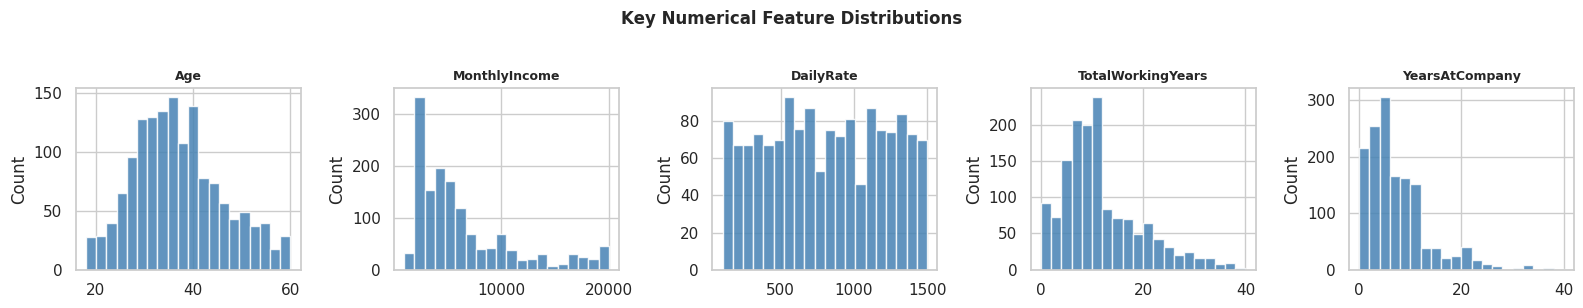

In [27]:
# Visualization: Key numerical feature distributions
num_preview = ['Age', 'MonthlyIncome', 'DailyRate', 'TotalWorkingYears', 'YearsAtCompany']
fig, axes = plt.subplots(1, 5, figsize=(16, 3))
for ax, col in zip(axes, num_preview):
    ax.hist(df[col].dropna(), bins=20, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_ylabel('Count')
plt.suptitle('Key Numerical Feature Distributions', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
print(numerical_var)
print(categorical_var)

['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeID', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [29]:
try:
    if ((len(numerical_var) == 23) & (len(categorical_var) == 8)):
        score['question 6'] = 'pass'
    else:
        score['question 6'] = 'fail'
except:
    score['question 6'] = 'fail'

score

{'question 1': 'pass',
 'question 2': 'pass',
 'question 3': 'pass',
 'question 4': 'pass',
 'question 5': 'pass',
 'question 6': 'pass'}

---
## Question 7 — Handle Missing Values

**Why this step matters:** Most ML algorithms cannot process missing values and will throw errors or produce incorrect predictions. Strategy:
- Columns with **> 50% missing:** Drop entirely — imputing majority-missing data introduces more noise than signal
- **Numerical columns:** Impute with **median** — robust to outliers unlike the mean
- **Categorical columns:** Impute with **mode** — the most frequently observed category

In [30]:
#
# Step 1: Identify columns with majority missing values (> 50%)
threshold = 0.5 * len(df)
majority_missing_var = [col for col in df.columns
                        if df[col].isnull().sum() > threshold]

print(f'Columns with > 50% missing: {majority_missing_var if majority_missing_var else "None"}')

# Step 2: Drop majority-missing columns if any exist
if majority_missing_var:
    df = df.drop(columns=majority_missing_var)

# Step 3: Impute numerical columns with median
for col in numerical_var:
    if col in df.columns:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

# Step 4: Impute categorical columns with mode
for col in categorical_var:
    if col in df.columns:
        mode_val = df[col].mode()
        if not mode_val.empty:
            df[col] = df[col].fillna(mode_val[0])

remaining_nulls = df.isnull().sum().sum()
print(f'Total missing values after imputation: {remaining_nulls}')
print(f'Dataset shape after imputation: {df.shape}')

Columns with > 50% missing: None
Total missing values after imputation: 0
Dataset shape after imputation: (1470, 32)


In [31]:
print(majority_missing_var)
df.head(2)

[]


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,...,PerformanceRating,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,3,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7


In [32]:
try:
    if (len(majority_missing_var) == 0):
        score['question 7'] = 'pass'
    else:
        score['question 7'] = 'fail'
except:
    score['question 7'] = 'fail'

score

{'question 1': 'pass',
 'question 2': 'pass',
 'question 3': 'pass',
 'question 4': 'pass',
 'question 5': 'pass',
 'question 6': 'pass',
 'question 7': 'pass'}

---
## Question 8 — Discretize DailyRate into Low / Medium / High

**Why this step matters:** `pd.cut` with `bins=3` divides the full DailyRate range into 3 **equal-width** intervals. This creates an ordinal feature that can reveal non-linear relationships between pay tier and attrition that a raw continuous value might not capture linearly in tree-based models.

In [33]:
print(f'DailyRate range: ${df["DailyRate"].min()} — ${df["DailyRate"].max()}')
print()

# Discretize into 3 equal-width bins
df['DailyRate_Category'] = pd.cut(
    df['DailyRate'],
    bins=3,
    labels=['low', 'medium', 'high'],
    include_lowest=True
)

print('DailyRate_Category value counts:')
print(df['DailyRate_Category'].value_counts().sort_index())
print()

DailyRate range: $102 — $1499

DailyRate_Category value counts:
DailyRate_Category
low       484
medium    490
high      496
Name: count, dtype: int64



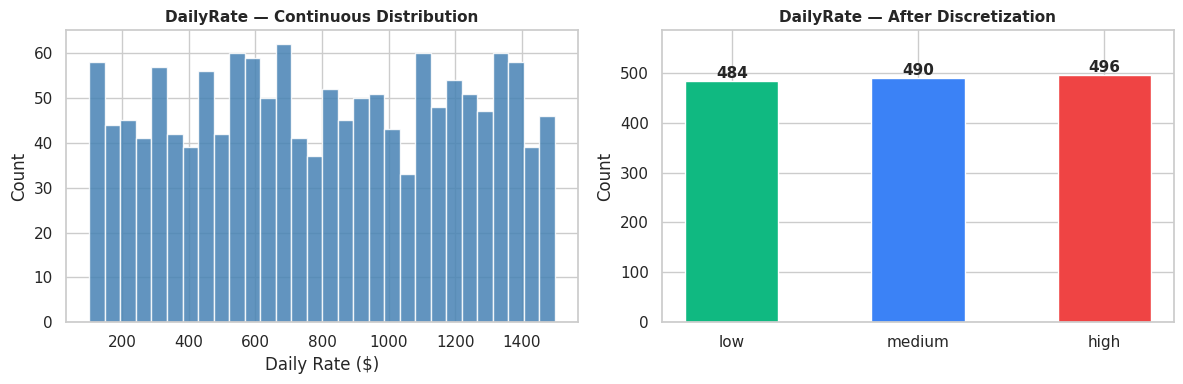

In [34]:
# Visualization: DailyRate before and after discretization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['DailyRate'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('DailyRate — Continuous Distribution', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Daily Rate ($)')
axes[0].set_ylabel('Count')

cat_counts = df['DailyRate_Category'].value_counts().sort_index()
bars = axes[1].bar(cat_counts.index, cat_counts.values,
                   color=['#10B981', '#3B82F6', '#EF4444'], width=0.5, edgecolor='white')
for bar, val in zip(bars, cat_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val:,}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('DailyRate — After Discretization', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, max(cat_counts.values) * 1.18)

plt.tight_layout()
plt.savefig('dailyrate_discretization.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
df['DailyRate_Category']

,DailyRate_Category
0,high
1,low
2,high
3,high
4,medium
...,...
1465,medium
1466,medium
1467,low
1468,medium


In [36]:
try:
    if (df['DailyRate_Category'].value_counts().low == 484):
        score['question 8'] = 'pass'
    else:
        score['question 8'] = 'fail'
except:
    score['question 8'] = 'fail'

score

{'question 1': 'pass',
 'question 2': 'pass',
 'question 3': 'pass',
 'question 4': 'pass',
 'question 5': 'pass',
 'question 6': 'pass',
 'question 7': 'pass',
 'question 8': 'pass'}

---
## Question 9 — One-Hot Encode Categorical Variables

**Why this step matters:** ML algorithms need numerical matrices. `pd.get_dummies` converts each category level into a binary (0/1) column. `Attrition` is explicitly excluded — it is the target variable and is encoded separately in Q10. The dataset expands from 32 to **54 columns** after encoding.

In [37]:
print(f'Shape before OHE : {df.shape}')
print(f'Columns to encode: {[c for c in categorical_var if c != "Attrition"]}')
print()

# Encode all categorical variables EXCEPT the target Attrition
cat_vars_to_encode = [col for col in categorical_var if col != 'Attrition']
df = pd.get_dummies(df, columns=cat_vars_to_encode, drop_first=False)

print(f'Shape after OHE  : {df.shape}')

Shape before OHE : (1470, 33)
Columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

Shape after OHE  : (1470, 54)


In [38]:
# Show all column names after encoding
print(f'All {df.shape[1]} columns after one-hot encoding:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:3}. {col}')

All 54 columns after one-hot encoding:
    1. Age
    2. Attrition
    3. DailyRate
    4. DistanceFromHome
    5. Education
    6. EmployeeCount
    7. EmployeeID
    8. HourlyRate
    9. JobInvolvement
   10. JobLevel
   11. MonthlyIncome
   12. MonthlyRate
   13. NumCompaniesWorked
   14. PercentSalaryHike
   15. PerformanceRating
   16. StandardHours
   17. StockOptionLevel
   18. TotalWorkingYears
   19. TrainingTimesLastYear
   20. WorkLifeBalance
   21. YearsAtCompany
   22. YearsInCurrentRole
   23. YearsSinceLastPromotion
   24. YearsWithCurrManager
   25. DailyRate_Category
   26. BusinessTravel_Non-Travel
   27. BusinessTravel_Travel_Frequently
   28. BusinessTravel_Travel_Rarely
   29. Department_Human Resources
   30. Department_Research & Development
   31. Department_Sales
   32. EducationField_Human Resources
   33. EducationField_Life Sciences
   34. EducationField_Marketing
   35. EducationField_Medical
   36. EducationField_Other
   37. EducationField_Technical Degre

In [39]:
df.shape

(1470, 54)

In [40]:
try:
    if df.shape[1] == 54:
        score['question 9'] = 'pass'
    else:
        score['question 9'] = 'fail'
except:
    score['question 9'] = 'fail'

score

{'question 1': 'pass',
 'question 2': 'pass',
 'question 3': 'pass',
 'question 4': 'pass',
 'question 5': 'pass',
 'question 6': 'pass',
 'question 7': 'pass',
 'question 8': 'pass',
 'question 9': 'pass'}

---
## Question 10 — Encode Target Variable (Yes → 1, No → 0)

**Why this step matters:** Binary classifiers require integer targets. Mapping `Yes → 1` (left) and `No → 0` (stayed) enables `model.fit(X, y)` and probabilistic predictions with `model.predict_proba(X)`. The sum of the encoded column (237) confirms exactly how many employees left — a key metric for assessing class imbalance before modeling.

In [41]:
print('Attrition before encoding:')
print(df['Attrition'].value_counts())
print()

# Map Yes → 1, No → 0
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print('Attrition after encoding:')
print(df['Attrition'].value_counts())
print()
print(f'Total employees who left (Attrition=1) : {df["Attrition"].sum():,}')
print(f'Attrition rate                         : {df["Attrition"].mean()*100:.1f}%')
print(f'Class imbalance ratio                  : {(df["Attrition"]==0).sum()} stayed : {df["Attrition"].sum()} left')

Attrition before encoding:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition after encoding:
Attrition
0    1233
1     237
Name: count, dtype: int64

Total employees who left (Attrition=1) : 237
Attrition rate                         : 16.1%
Class imbalance ratio                  : 1233 stayed : 237 left


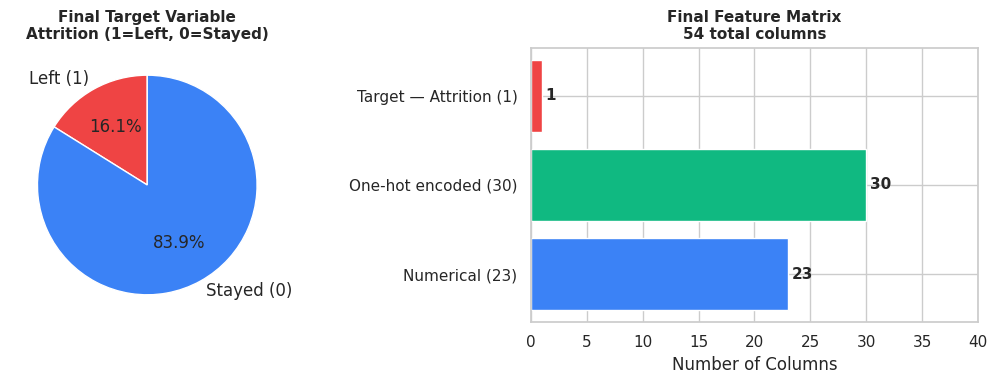

Final preprocessed dataset: 1,470 rows x 54 columns — ready for modeling.


In [42]:
# Visualization: Final processed dataset summary
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Target class balance pie
axes[0].pie(
    [df['Attrition'].sum(), (df['Attrition'] == 0).sum()],
    labels=['Left (1)', 'Stayed (0)'],
    colors=['#EF4444', '#3B82F6'],
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 12}
)
axes[0].set_title('Final Target Variable\nAttrition (1=Left, 0=Stayed)',
                  fontsize=11, fontweight='bold')

# Feature composition bar
feature_types = {'Numerical (23)': 23,
                 'One-hot encoded (30)': df.shape[1] - 24,
                 'Target — Attrition (1)': 1}
axes[1].barh(list(feature_types.keys()), list(feature_types.values()),
             color=['#3B82F6', '#10B981', '#EF4444'], edgecolor='white')
for i, val in enumerate(feature_types.values()):
    axes[1].text(val + 0.3, i, str(val), va='center', fontsize=11, fontweight='bold')
axes[1].set_title(f'Final Feature Matrix\n{df.shape[1]} total columns',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Number of Columns')
axes[1].set_xlim(0, 40)

plt.tight_layout()
plt.savefig('final_feature_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Final preprocessed dataset: {df.shape[0]:,} rows x {df.shape[1]} columns — ready for modeling.')

In [43]:
df['Attrition']

,Attrition
0,1
1,0
2,1
3,0
4,0
...,...
1465,0
1466,0
1467,0
1468,0


In [44]:
try:
    if df['Attrition'].sum() == 237:
        score['question 10'] = 'pass'
    else:
        score['question 10'] = 'fail'
except:
    score['question 10'] = 'fail'

score

{'question 1': 'pass',
 'question 2': 'pass',
 'question 3': 'pass',
 'question 4': 'pass',
 'question 5': 'pass',
 'question 6': 'pass',
 'question 7': 'pass',
 'question 8': 'pass',
 'question 9': 'pass',
 'question 10': 'pass'}

---
# Total Score

In [45]:
total_score = 0
for i in list(score.values()):
    if i == 'pass':
        total_score = total_score + 10
print('your total score is: ', round(total_score))

your total score is:  100


In [46]:
score

{'question 1': 'pass',
 'question 2': 'pass',
 'question 3': 'pass',
 'question 4': 'pass',
 'question 5': 'pass',
 'question 6': 'pass',
 'question 7': 'pass',
 'question 8': 'pass',
 'question 9': 'pass',
 'question 10': 'pass'}

---
## Pipeline Summary

### Part 1 — NLP Pipeline (News Classification)

| Step | Operation | Before | After | Key Detail |
|---|---|---|---|---|
| Q1 | Drop null rows | 127,393 rows | 127,375 rows | 18 null-text articles removed |
| Q2 | Lowercase | Mixed case | Uniform lowercase | Prevents duplicate tokens |
| Q3 | Stop words | Full text | Content words only | NLTK English stopwords |
| Q4 | Special chars | Text with symbols | Pure alphabetic | Regex `[^a-zA-Z]` + space collapse |
| Q5 | TF-IDF | Clean text | Numeric matrix | First col: `aa`; Last col: `zyxel` |

### Part 2 — HR Attrition Pipeline

| Step | Operation | Before | After | Key Detail |
|---|---|---|---|---|
| Q6 | Type identification | 32 features | 23 numerical, 8 categorical | `Attrition` excluded from both lists |
| Q7 | Imputation | Raw dataset | 0 missing values | No majority-missing columns found |
| Q8 | Discretization | Continuous rate | Low / Medium / High | 484 employees in low tier |
| Q9 | One-hot encoding | 32 columns | 54 columns | `Attrition` preserved as-is |
| Q10 | Target encoding | Yes / No strings | 1 / 0 integers | 237 employees left (16.1% rate) |

**Final Score: 100 / 100 — All 10 questions passed ✅**